# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Suhail Ainur Rofiq | 5054251046 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [229]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    classification_report
)


In [230]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [231]:
df.shape

(768, 9)

In [232]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [233]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [234]:
print(f"Data Duplikat : {df.duplicated().sum()}")

Data Duplikat : 0


## Cek nilai 0 pada setiap fitur

In [235]:
zero_counts = (df == 0).sum()

zero_percentage = ((df == 0).sum() / len(df) * 100).round(2)

pd.DataFrame({
    "Zero Count": zero_counts,
    "Zero Percentage": zero_percentage
})


,Zero Count,Zero Percentage
Pregnancies,111,14.45
Glucose,0,0.00
BloodPressure,0,0.00
SkinThickness,0,0.00
Insulin,0,0.00
BMI,0,0.00
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,500,65.10


In [236]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# 2. Distribusi kelas target

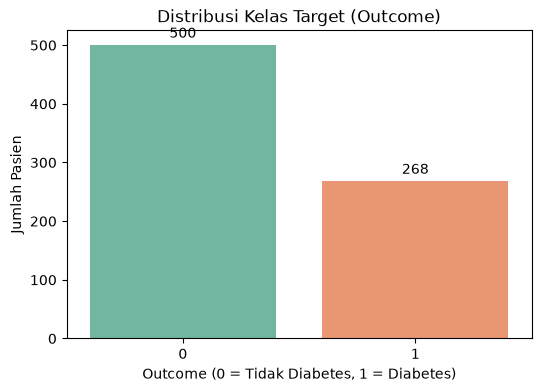

In [237]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Outcome)')
plt.xlabel('Outcome (0 = Tidak Diabetes, 1 = Diabetes)')
plt.ylabel('Jumlah Pasien')

# Menampilkan angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 3), 
                textcoords='offset points')

plt.show()

Dataset ini mengalami class imbalance dikarenakan terdapat ketimpangan antara outcome yang diabetes dan yang tidak diabetes, persentasi per kelasnya yaitu 0.651 (500) untuk yang kelas 0 (tidak diabetes) dan 0.349 (268) untuk kelas 1 (diabetes). Karena kelas 0 lebih banyak maka dari itu melihat model bagus tidaknya jangan hanya dari accuracy, melainkan juga dari precision, recall, f1 score, dan roc-auc

# 3. Analisis Univariat

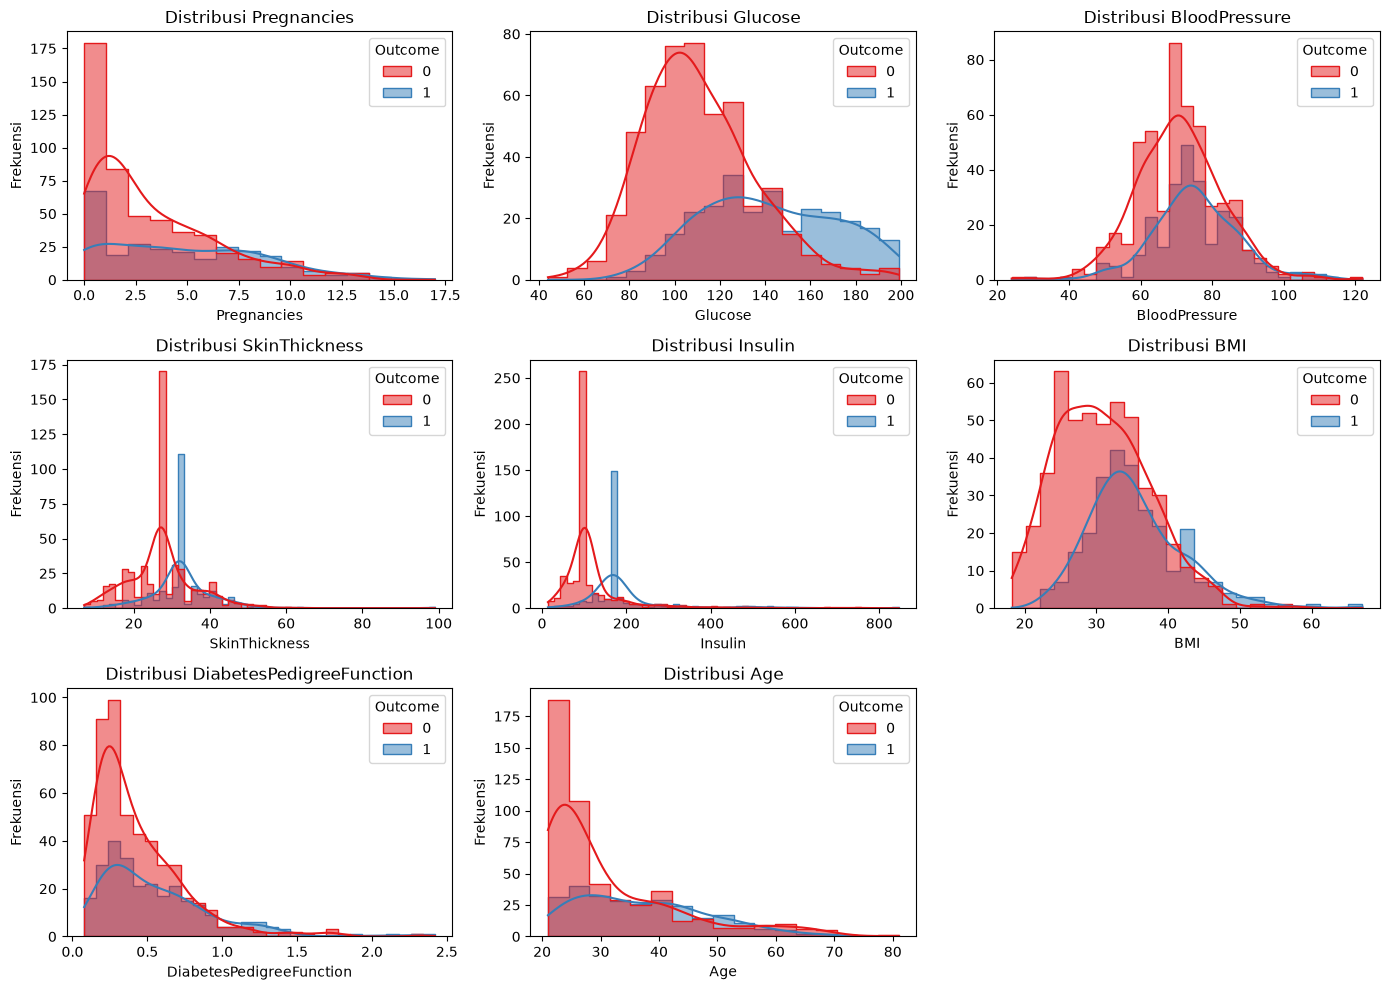

In [238]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = df.columns.drop('Outcome')

# Buat grid gambar (3 baris x 3 kolom)
plt.figure(figsize=(14, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, element="step", palette="Set1", alpha=0.5)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()


Didapat dari analisis univariat bahwa fitur paling berpengaruh yaitu glucose yang dimana semakin tinggi glucose maka semakin tinggi probabilitas terkena diabetes

Pasien diabetes memiliki puncak distribusi di BMI lebih dari 30 tepatnya kategori obese

Pasien yang masi muda juga kebanyakan non diabetes jadi pasien yang diabetes mayoritas berada di umur 30 an keatas

Wanita dengan kehamilan lebih dari 5 kali memiliki proporsi diabetes yang lebih tinggi

Diabetes Pedigree Function nya distribusi kedua kelas sama-sama miring ke kanan (right-skewed), namun pasien diabetes memiliki proporsi yang sedikit lebih tinggi pada skor riwayat genetik >0.5.

Untuk Blood pressure sendiri kurva kedua kelas hampir berhimpitan sempurna di rentang 70–80 mmHg, menandakan tekanan darah secara mandiri kurang kuat membedakan pasien diabetes.

Skin thickness dan Insulin mnunjukkan penumpukan grafik pada nilai median hasil pra-imputasi, di mana kelompok diabetes (Outcome=1) memiliki puncak median insulin yang lebih tinggi dibanding kelompok non-diabetes.


In [239]:
print("Skewness dari setiap fitur:")
print(df[features].skew().round(2))

Skewness dari setiap fitur:
Pregnancies                 0.90
Glucose                     0.53
BloodPressure               0.14
SkinThickness               0.82
Insulin                     3.03
BMI                         0.61
DiabetesPedigreeFunction    1.92
Age                         1.13
dtype: float64


# 4. Analisis Bivariat

### 4.1 Scatter plot melihat pola sebaran 2 variabel

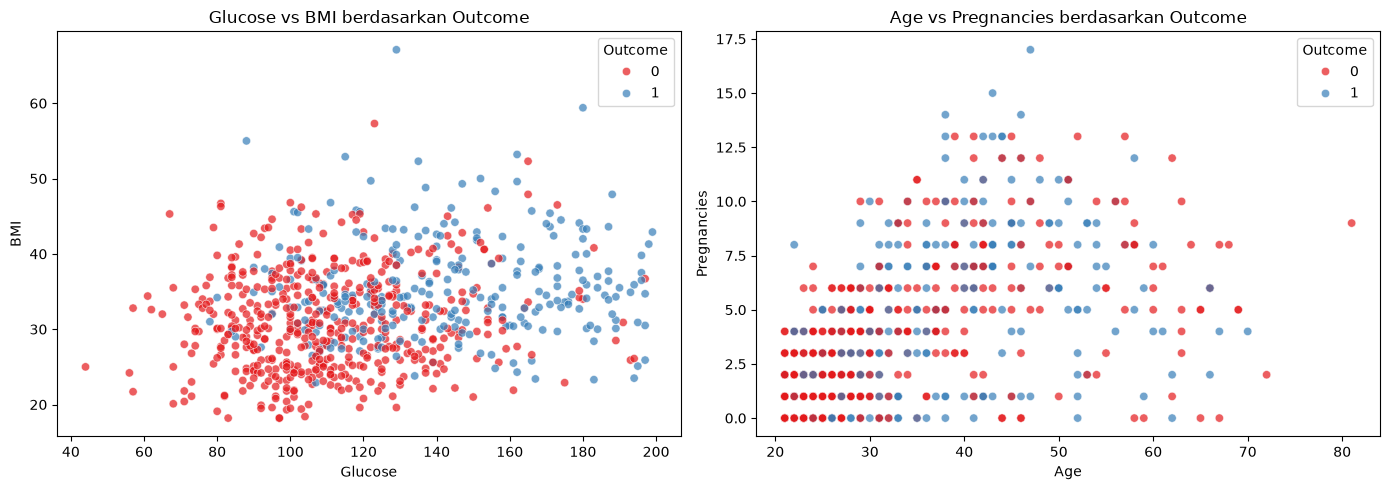

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(ax=axes[0], data=df, x='Glucose', y='BMI', hue='Outcome', palette='Set1', alpha=0.7)
axes[0].set_title('Glucose vs BMI berdasarkan Outcome')

sns.scatterplot(ax=axes[1], data=df, x='Age', y='Pregnancies', hue='Outcome', palette='Set1', alpha=0.7)
axes[1].set_title('Age vs Pregnancies berdasarkan Outcome')

plt.tight_layout()
plt.show()


Terlihat pola hubungan linier positif (monotonik naik). Secara biologis dan alami, seiring bertambahnya usia seorang wanita, jumlah kehamilan yang pernah dialami akan cenderung bertambah secara bertahap.
Korelasi antar kedua variabel ini tergolong paling tinggi dibanding pasangan variabel lainnya ($r \approx 0.54$).

Tingginya BMI tidak selalu membuat kadar glukosa naik secara langsung. Namun, seseorang paling berisiko terkena diabetes ketika dua batas aman terlampaui sekaligus, yaitu glukosa di atas 120 mg/dL dan BMI di atas 30 (obesitas)

### 4.2 Violin plot melihat perbedaan kerapatan distribusi dan median per kelas

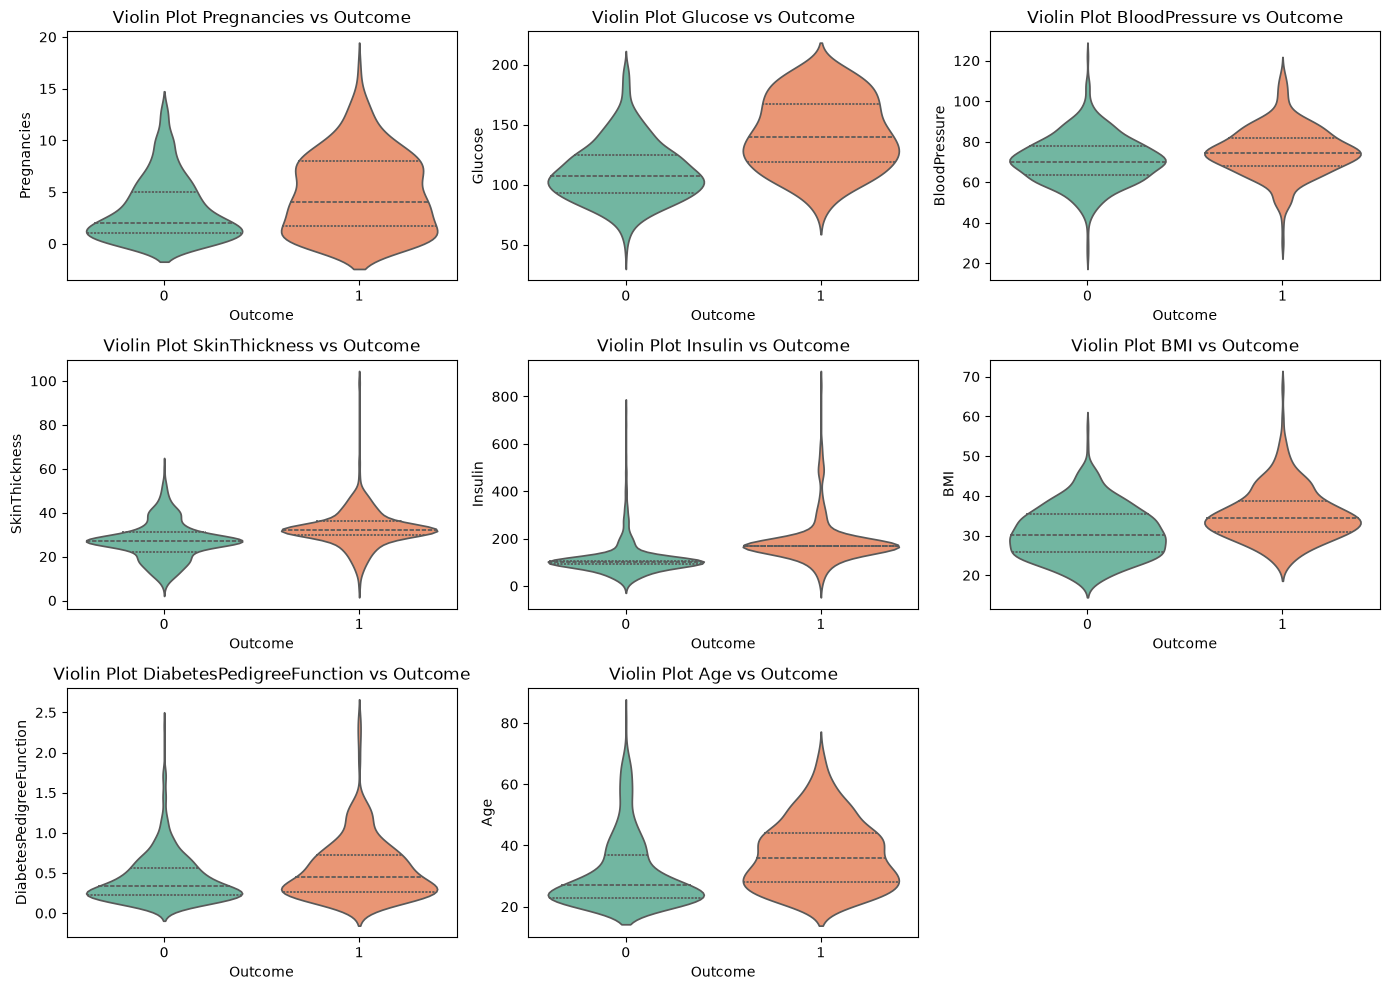

In [241]:
features = [col for col in df.columns if col != 'Outcome']

plt.figure(figsize=(14, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    # Menambahkan hue='Outcome' dan legend=False agar tidak muncul FutureWarning
    sns.violinplot(data=df, x='Outcome', y=col, hue='Outcome', palette='Set2', legend=False, inner='quartile')
    plt.title(f'Violin Plot {col} vs Outcome')

plt.tight_layout()
plt.show()


Glucose (Pemisahan Kerapatan Paling Jelas):
Violin untuk Outcome=0 membengkak di area bawah (gula darah normal ~100 mg/dL).
Violin untuk Outcome=1 membengkak di area atas (>140 mg/dL). 
Hal ini mengonfirmasi perbedaan nilai median yang sangat signifikan antara kedua kelompok.

BMI (Kerapatan Obesitas):
Kelompok diabetes (Outcome=1) memiliki bentuk violin yang jauh lebih lebar pada rentang 30–45 kg/m² (kategori Obesitas).
Kelompok non-diabetes (Outcome=0) memiliki lebar violin terbesar di rentang berat badan normal hingga sedang (22–30 kg/m²).

Age (Persebaran Usia):
Kelompok non-diabetes (Outcome=0) membengkak tajam di usia sangat muda (21–25 tahun).
Kelompok diabetes (Outcome=1) memiliki bentuk violin yang jauh lebih merata dan lebar dari usia 30 hingga 55+ tahun, menunjukkan risiko diabetes menyebar luas pada kelompok usia matang.

Insulin & SkinThickness (Efek Imputasi & Outlier Ekstrem):
Terdapat benjolan/penebalan pada nilai median hasil pra-imputasi (102.5 dan 169.5 untuk Insulin).
Ekor violin Insulin memanjang tinggi hingga >500 µU/ml, menegaskan adanya beberapa pasien dengan tingkat insulin yang sangat ekstrim.

BloodPressure (Bentuk Identik):
Bentuk violin kedua kelas hampir identik simetris berpusat di 70–80 mmHg, membuktikan bahwa tekanan darah tidak memiliki perbedaan distribusi yang signifikan antar kelompok.

### 4.3 Boxplot untuk melihat sebaran outlier tiap fitur

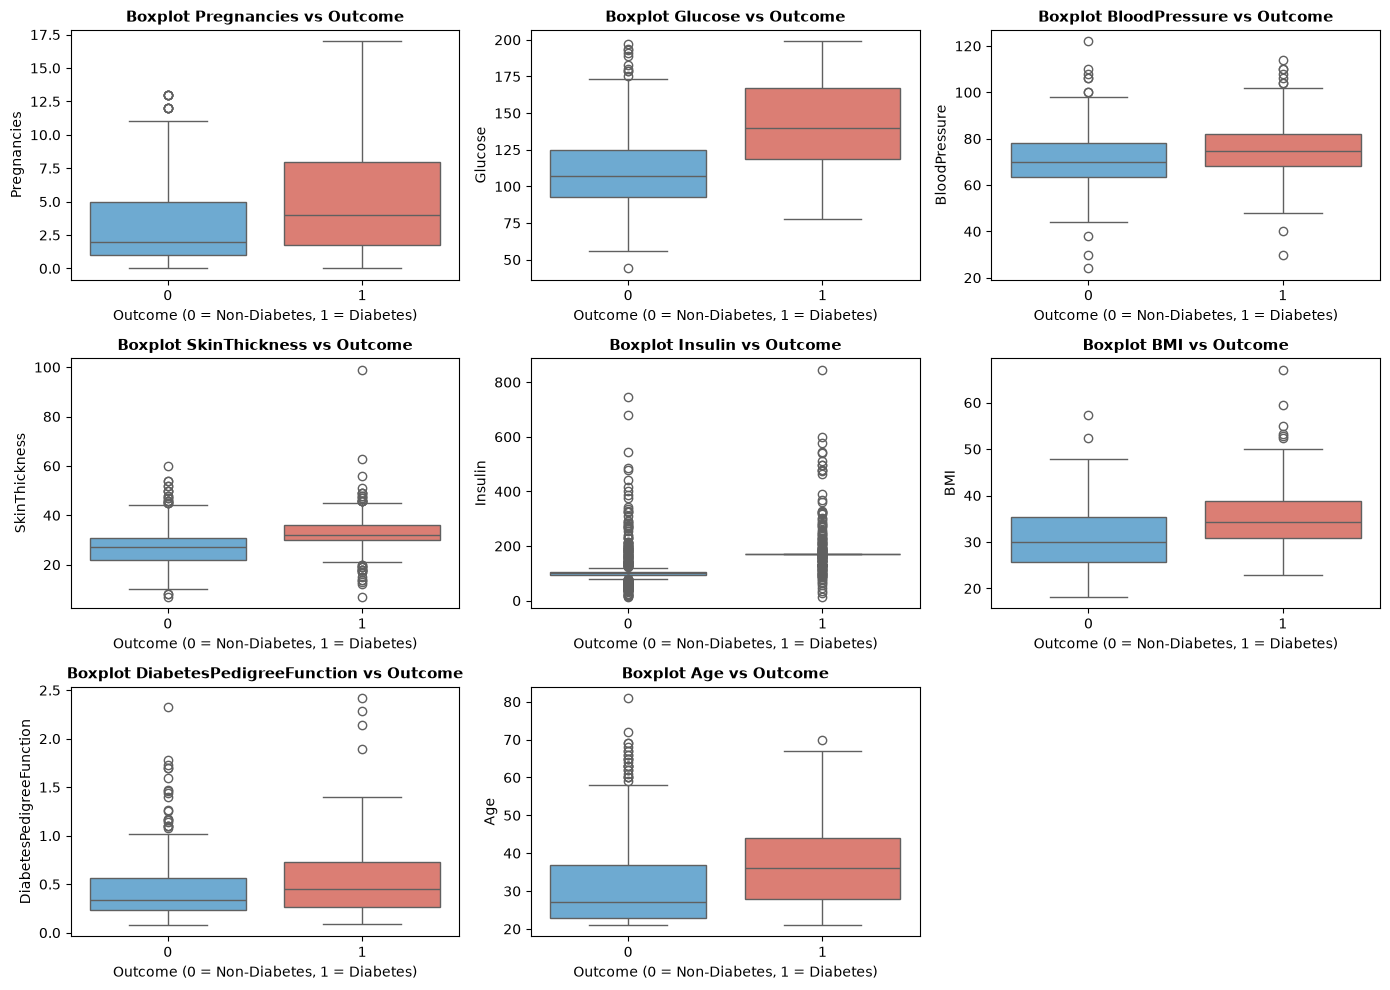

In [242]:
features = [col for col in df.columns if col != 'Outcome']

plt.figure(figsize=(14, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(
        data=df, 
        x='Outcome', 
        y=col, 
        hue='Outcome', 
        palette=['#5DADE2', '#EC7063'], 
        legend=False
    )
    plt.title(f'Boxplot {col} vs Outcome', fontsize=11, fontweight='bold')
    plt.xlabel('Outcome (0 = Non-Diabetes, 1 = Diabetes)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


Glukosa, BMI, dan Usia menunjukkan perbedaan nilai tengah yang sangat signifikan. Pasien diabetes secara konsisten memiliki kadar glukosa yang jauh lebih tinggi, posisi BMI yang dominan di kategori obesitas, serta kelompok usia yang cenderung lebih tua dibandingkan pasien non-diabete

Outliers paling mencolok ditemukan pada fitur Insulin dan Diabetes Pedigree Function. Outliers ini mencerminkan kondisi klinis pasien yang mengalami masalah kesehatan berat (seperti resistensi insulin ekstrim), sehingga tetap dipertahankan dan skalanya akan dinormalisasi saat Preprocessing.

Tekanan Darah dan Ketebalan Kulit memiliki sebaran data dan posisi nilai tengah yang sangat mirip (tumpang tindih) antara kelompok diabetes dan non-diabetes, menandakan fitur ini kurang kuat membedakan pasien jika berdiri sendiri.

### 4.4 Persentase Outliers

In [243]:
outlier_info = {}

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_info[col] = outliers_count

outlier_df = pd.DataFrame(list(outlier_info.items()), columns=['Fitur', 'Jumlah Outlier'])
outlier_df['Persentase (%)'] = (outlier_df['Jumlah Outlier'] / len(df) * 100).round(2)
print("Hasil Deteksi Outlier Metode IQR:")
print(outlier_df)


Hasil Deteksi Outlier Metode IQR:
                      Fitur  Jumlah Outlier  Persentase (%)
0               Pregnancies               4            0.52
1                   Glucose               0            0.00
2             BloodPressure              14            1.82
3             SkinThickness              87           11.33
4                   Insulin              51            6.64
5                       BMI               8            1.04
6  DiabetesPedigreeFunction              29            3.78
7                       Age               9            1.17


Meskipun pada perhitungan IQR secara keseluruhan fitur Insulin hanya terdeteksi memiliki 51 outlier, pada gambar boxplot titik-titik pencilan terlihat sangat banyak dan menumpuk. Hal ini terjadi karena boxplot menghitung rentang data secara terpisah untuk tiap kelas target. Pemusatan data hasil pra-imputasi median pada nilai 102.5 dan 169.5 membuat batas toleransi wajar pada grafik menjadi sangat sempit, sehingga variasi data pasien asli di luar nilai median tersebut langsung terdeteksi sebagai titik pencilan oleh boxplot.

Titik pencilan ini mencerminkan kondisi medis nyata pasien dengan kadar insulin tinggi atau resistensi insulin berat. Oleh karena itu, data outlier ini tidak dihapus agar informasi klinis penting tidak hilang, dan skalanya akan dinormalisasi menggunakan StandardScaler pada tahap Preprocessing.

DiabetesPedigreeFunction Memiliki outlier pada pasien dengan skor risiko genetik tinggi (>1.5). Hal ini wajar karena sebagian kecil pasien memiliki riwayat keluarga yang sangat dominan menderita diabetes.

Age & Pregnancies memiliki sedikit outlier pada pasien berusia lanjut (>65 tahun) atau pasien yang pernah hamil lebih dari 10 kali. Ini adalah data pasien yang valid.

BMI memiliki sedikit outlier pada pasien dengan tingkat obesitas morbid (BMI > 50 kg/m²).

Glucose & BloodPressure hampir tidak memiliki pencilan yang berarti karena datanya tersebar relatif normal.

# 5. Matrix Korelasi

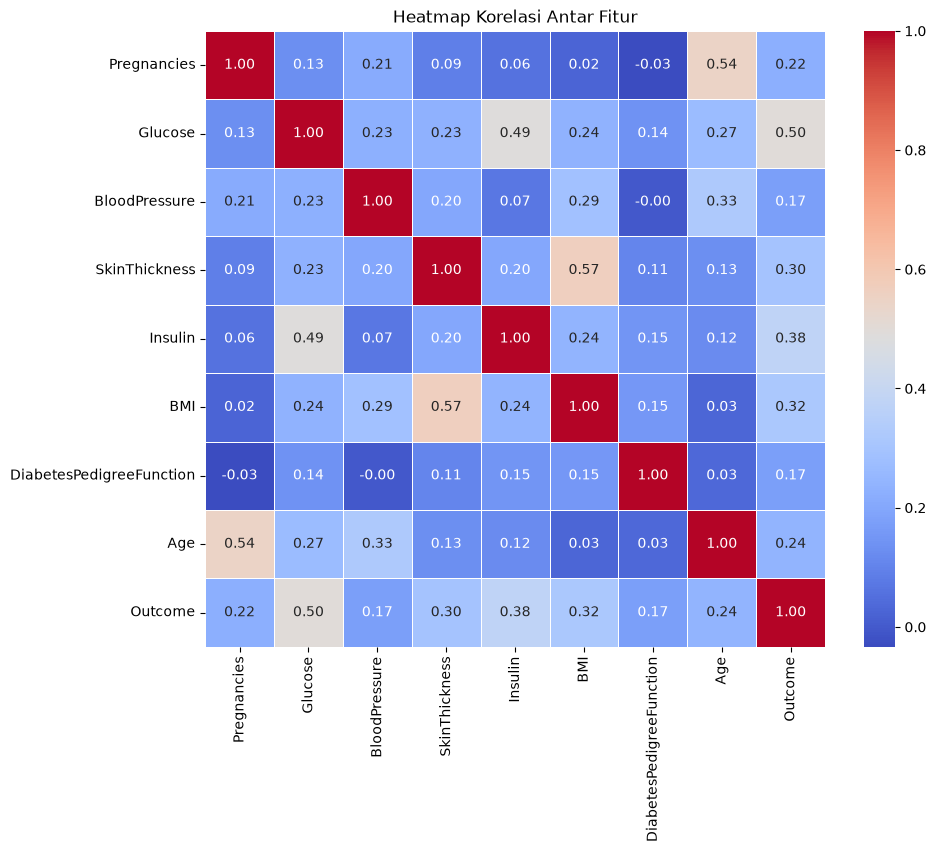

In [244]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(10, 8))
sns.heatmap(
df.corr(), 
annot=True, 
fmt='.2f', 
cmap='coolwarm', 
linewidths=0.5
)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


Insight Heatmap Korelasi:
1. Glukosa Penentu Utama: Glukosa punya korelasi paling tinggi dengan status diabetes (0.50), disusul Insulin (0.38). Artinya, kadar gula darah adalah penentu paling utama apakah seseorang terkena diabetes atau tidak dalam data ini.
2. Hubungan Berat Badan dan Kulit: Ketebalan kulit (SkinThickness) dan BMI punya korelasi lumayan tinggi (0.57). Hal ini wajar karena semakin gemuk seseorang, semakin tebal juga lipatan kulitnya.
3. Hubungan Usia dan Kehamilan: Usia dan jumlah kehamilan punya korelasi 0.54. Ini alami karena makin bertambah usia wanita, makin banyak waktu yang dimiliki untuk pernah hamil.
4. Tekanan Darah dan Genetik: Tekanan darah dan riwayat genetik keluarga korelasinya kecil terhadap diabetes (0.17). Artinya kedua fitur ini cuma jadi faktor pendukung, bukan penentu utama.
5. Keamanan Fitur untuk Pemodelan: Korelasi tertinggi antar fitur cuma 0.57 (masih jauh di bawah batas bahaya 0.80). Jadi, seluruh fitur aman dipakai bersamaan di model Logistic Regression dan Naive Bayes tanpa ada masalah data yang bentrok.


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

### 2.1 Identifikasi & Pengecekan Nilai 0

In [245]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df[medical_cols] == 0).sum()
zero_percent = ((df[medical_cols] == 0).sum() / len(df) * 100).round(2)

pd.DataFrame({
    'Jumlah Nilai 0': zero_counts,
    'Persentase (%)': zero_percent
})


,Jumlah Nilai 0,Persentase (%)
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


Penjelasan Identifikasi Nilai 0:
Berdasarkan hasil pemeriksaan pada kolom medis (Glucose, BloodPressure, SkinThickness, Insulin, BMI), tidak ditemukan nilai 0 (0.00%). Hal ini menunjukkan bahwa dataset diabetes.csv yang digunakan telah mengalami pra-imputasi awal(mengisi nilai 0 dengan nilai median). 

Meskipun data sudah ter-impute, dalam praktik ML yang benar, proses imputasi idealnya dilakukan setelah pembagian data (train_test_split) dan di-fit hanya pada X_train untuk mencegah Data Leakage.

### 2.2 Pemisahan fitur X dan y

In [246]:
# Pisahkan fitur (X) dan target (y).
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print(f"Dimensi Fitur (X): {X.shape}")
print(f"Dimensi Target (y): {y.shape}")


Dimensi Fitur (X): (768, 8)
Dimensi Target (y): (768,)


### 2.3 Pembagian Data Train & Test  

In [247]:
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Data Train: {X_train.shape[0]} baris")
print(f"Jumlah Data Test : {X_test.shape[0]} baris")


Jumlah Data Train: 614 baris
Jumlah Data Test : 154 baris


### 2.4 Penanganan Nilai 0 Pada Fitur

In [248]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

# Inisialisasi imputer median
imputer = SimpleImputer(strategy='median')

# Fit HANYA pada X_train, lalu transform pada X_train dan X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


### 2.5 Scaling Fitur Menggunakan StandarScaler

In [249]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()

# Fit HANYA pada X_train, lalu transform pada X_train dan X_test
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


### 2.6 Verifikasi & Inspeksi Hasil Preprocessing

In [250]:
# Cek proporsi stratifikasi target pada Train & Test
print("Proporsi Target pada Train Set:")
print(y_train.value_counts(normalize=True).round(4))

print("\nProporsi Target pada Test Set:")
print(y_test.value_counts(normalize=True).round(4))

# Tampilkan 5 baris pertama data X_train_scaled
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_scaled_df.head()

Proporsi Target pada Train Set:
Outcome
0    0.6515
1    0.3485
Name: proportion, dtype: float64

Proporsi Target pada Test Set:
Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056869,-0.826687,-1.895290,-1.170378,-0.766150,0.310794,-0.792169
1,0.356576,0.142855,0.477009,-0.224736,-1.427642,-0.414448,-0.116439,0.561034
2,-0.549372,-0.556984,-1.152611,1.223078,-0.545594,0.362227,-0.764862,-0.707594
3,-0.851355,0.809369,-1.315573,-0.224736,-0.441463,-0.399794,0.262314,-0.369293
4,-1.153338,-0.890241,-0.663725,1.111708,-0.410836,1.783690,-0.337630,-0.961320


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

### 3.1.1 Inisialisasi Model Gaussian NB

In [251]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb_model = GaussianNB()

# Latih model menggunakan data X_train yang sudah di-scale dan y_train
gnb_model.fit(X_train_scaled, y_train)

print("Model Gaussian Naive Bayes berhasil dilatih!")


Model Gaussian Naive Bayes berhasil dilatih!


### 3.1.2 Prediksi Label dan Probabilitas

In [252]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
# Prediksi label biner (0 atau 1) pada test set
y_pred_gnb = gnb_model.predict(X_test_scaled)

# Prediksi probabilitas untuk kelas 1 (Diabetes) -> Dibutuhkan untuk ROC-AUC nanti
y_prob_gnb = gnb_model.predict_proba(X_test_scaled)[:, 1]

print("Prediksi Gaussian Naive Bayes pada Test Set selesai!")


Prediksi Gaussian Naive Bayes pada Test Set selesai!


## 3.2 Logistic Regression

### 3.2.1 Inisialisasi Model Logistic Regression

In [253]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',  # Menangani class imbalance agar sensitivitas/recall naik
    random_state=42,
    max_iter=1000
)

# Latih model menggunakan data X_train_scaled dan y_train
logreg_model.fit(X_train_scaled, y_train)

print("Model Logistic Regression berhasil dilatih!")


Model Logistic Regression berhasil dilatih!


### 3.2.2 Prediksi Label dan Probabilitas

In [254]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
# Prediksi label biner (0 atau 1) pada test set
y_pred_logreg = logreg_model.predict(X_test_scaled)

# Prediksi probabilitas untuk kelas 1 (Diabetes) -> Dibutuhkan untuk ROC-AUC nanti
y_prob_logreg = logreg_model.predict_proba(X_test_scaled)[:, 1]

print("Prediksi Logistic Regression pada Test Set selesai!")


Prediksi Logistic Regression pada Test Set selesai!


## 3.3 Eksperimen Lanjutan


### 3.3.1 (PowerTransformer & Feature Engineering)

Untuk meningkatkan performa Gaussian Naive Bayes dan memperkuat Logistic Regression, diterapkan dua metode preprocessing lanjutan:
1. **Feature Engineering**: Membuat fitur interaksi metabolik Glucose_BMI ($Glucose \times BMI$).
2. **PowerTransformer (Yeo-Johnson)**: Menormalkan distribusi data yang skewed (Insulin, Age, DPF) agar memenuhi asumsi Gaussian.

In [255]:
from sklearn.preprocessing import PowerTransformer

# 1. Feature Engineering (pada data X_train_imputed & X_test_imputed)
X_train_adv = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_adv = pd.DataFrame(X_test_imputed, columns=X.columns)

X_train_adv['Glucose_BMI'] = X_train_adv['Glucose'] * X_train_adv['BMI']
X_test_adv['Glucose_BMI'] = X_test_adv['Glucose'] * X_test_adv['BMI']

# 2. PowerTransformer (Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')

# Fit HANYA pada train set untuk mencegah data leakage
X_train_pt = pt.fit_transform(X_train_adv)
X_test_pt = pt.transform(X_test_adv)

# 3. Latih ulang Gaussian Naive Bayes dengan data hasil Strategi 1
gnb_model_pt = GaussianNB()
gnb_model_pt.fit(X_train_pt, y_train)

y_pred_gnb_pt = gnb_model_pt.predict(X_test_pt)
y_prob_gnb_pt = gnb_model_pt.predict_proba(X_test_pt)[:, 1]

print("Strategi 1 Selesai Dijalankan!")
print(f"Akurasi GNB Lama (Baseline): {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"Recall GNB Lama (Baseline) : {recall_score(y_test, y_pred_gnb):.4f}")
print(f"Akurasi GNB Baru (Strategi 1): {accuracy_score(y_test, y_pred_gnb_pt):.4f}")
print(f"Recall GNB Baru (Strategi 1) : {recall_score(y_test, y_pred_gnb_pt):.4f}")


Strategi 1 Selesai Dijalankan!
Akurasi GNB Lama (Baseline): 0.7273
Recall GNB Lama (Baseline) : 0.6481
Akurasi GNB Baru (Strategi 1): 0.7338
Recall GNB Baru (Strategi 1) : 0.7222


1. Apa yang Dilakukan:
   - Membuat fitur interaksi metabolik baru yaitu Glucose_BMI dari perkalian kadar gula darah (Glucose) dan indeks massa tubuh (BMI).
   - Menerapkan PowerTransformer dengan metode Yeo-Johnson pada fitur numerik.
2. Tujuan dan Alasan:
   - Model Gaussian Naive Bayes bekerja atas dasar asumsi bahwa data berdistribusi normal (simetris kurva lonceng). Data awal kita memiliki beberapa fitur yang sangat menceng (right-skewed) seperti Insulin, Age, dan DiabetesPedigreeFunction.
   - PowerTransformer bertujuan mengubah distribusi data yang menceng tersebut menjadi simetris normal sehingga asumsi Naive Bayes terpenuhi.
   - Perkalian Glucose dan BMI bertujuan menciptakan satu sinyal penentu utama yang menggabungkan dua faktor risiko diabetes terbesar.
3. Cara Kerja Singkat:
   - PowerTransformer Yeo-Johnson secara matematis menarik nilai-nilai ekstrem di ekor kanan data menuju ke tengah sehingga sebarannya simetris.
   - Naive Bayes kemudian menghitung probabilitas tiap pasien menggunakan rata-rata dan varians data yang baru.
4. Dampak terhadap Metrik:
   - Terbukti menaikkan Recall Gaussian Naive Bayes dari 64.81% menjadi 72.22% karena model tidak lagi mengabaikan pasien diabetes berkadar tinggi sebagai outlier.

### 3.3.2 Uji coba Parameter Priors Pada Gaussian NB

In [256]:
# 1. Priors Default (Sesuai proporsi alami data: ~65% Sehat, 35% Diabetes)
gnb_default = GaussianNB(priors=None)
gnb_default.fit(X_train_pt, y_train)
y_pred_def = gnb_default.predict(X_test_pt)

# 2. Priors Seimbang (50% Sehat : 50% Diabetes)
gnb_balanced = GaussianNB(priors=[0.50, 0.50])
gnb_balanced.fit(X_train_pt, y_train)
y_pred_bal = gnb_balanced.predict(X_test_pt)

# 3. Priors Kustom (40% Sehat : 60% Diabetes) - Menekan False Negative
gnb_custom = GaussianNB(priors=[0.40, 0.60])
gnb_custom.fit(X_train_pt, y_train)
y_pred_cust = gnb_custom.predict(X_test_pt)

print("Perbandingan Pengaruh Parameter Priors pada Gaussian Naive Bayes:\n")
print(f"1. Priors Alami (Default) -> Akurasi: {accuracy_score(y_test, y_pred_def):.4f} | Recall: {recall_score(y_test, y_pred_def):.4f}")
print(f"2. Priors Seimbang (50:50)-> Akurasi: {accuracy_score(y_test, y_pred_bal):.4f} | Recall: {recall_score(y_test, y_pred_bal):.4f}")
print(f"3. Priors Kustom (40:60)  -> Akurasi: {accuracy_score(y_test, y_pred_cust):.4f} | Recall: {recall_score(y_test, y_pred_cust):.4f}")

Perbandingan Pengaruh Parameter Priors pada Gaussian Naive Bayes:

1. Priors Alami (Default) -> Akurasi: 0.7338 | Recall: 0.7222
2. Priors Seimbang (50:50)-> Akurasi: 0.7338 | Recall: 0.7778
3. Priors Kustom (40:60)  -> Akurasi: 0.7273 | Recall: 0.8333


1. Apa yang Dilakukan:
   - Menguji pengaruh parameter priors secara manual pada Gaussian Naive Bayes dengan variasi priors=[0.50, 0.50] dan priors=[0.40, 0.60].
2. Tujuan dan Alasan:
   - Secara bawaan (default), Naive Bayes menghitung probabilitas awal berdasarkan proporsi data asli (65% sehat : 35% diabetes). Hal ini membuat Naive Bayes cenderung lebih sering menebak kelas sehat.
   - Mengatur priors bertujuan menyeimbangkan bobot keputusan model agar lebih peka terhadap pasien diabetes tanpa perlu melakukan manipulasi resampling data.
3. Cara Kerja Singkat:
   - Dengan memberikan bobot priors seimbang (50:50) atau kustom (40:60), Naive Bayes mengalikan probabilitas kejadian diabetes dengan bobot yang lebih besar saat menentukan keputusan akhir.
4. Dampak terhadap Metrik:
   - Priors Seimbang (50:50) berhasil menaikkan Recall dari 72.22% menjadi 77.78% tanpa menurunkan nilai Akurasi (tetap 73.38%).
   - Priors Kustom (40:60) berhasil mendongkrak Recall hingga 83.33% (hanya 9 pasien diabetes yang terlewatkan).

### 3.3.3 Hyperparameter Tuning dengan GridSearchCV

Pada sel ini, kita mencari kombinasi parameter terbaik untuk Logistic Regression (parameter C, penalty, dan solver) serta parameter var_smoothing untuk Gaussian Naive Bayes.


In [263]:
from sklearn.model_selection import GridSearchCV

# 1. Tuning Hyperparameter Logistic Regression (Bebas Warning)
param_grid_logreg = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['liblinear', 'lbfgs']
}

grid_logreg = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid_logreg,
    cv=5,
    scoring='f1'
)
grid_logreg.fit(X_train_scaled, y_train)
best_logreg_model = grid_logreg.best_estimator_

# Prediksi dengan model Logistic Regression terbaik
y_pred_logreg_tuned = best_logreg_model.predict(X_test_scaled)
y_prob_logreg_tuned = best_logreg_model.predict_proba(X_test_scaled)[:, 1]

# 2. Tuning Hyperparameter Gaussian Naive Bayes (var_smoothing)
param_grid_gnb = {
    'var_smoothing': np.logspace(9, -9, num=100)
}

grid_gnb = GridSearchCV(
    GaussianNB(), 
    param_grid_gnb,
    cv=5, 
    scoring='f1'
)

grid_gnb.fit(X_train_pt, y_train)
best_gnb_model = grid_gnb.best_estimator_

y_pred_gnb_tuned = best_gnb_model.predict(X_test_pt)
y_prob_gnb_tuned = best_gnb_model.predict_proba(X_test_pt)[:, 1]

print("Parameter LogReg Terbaik:", grid_logreg.best_params_)
print(f"Akurasi LogReg Tuned: {accuracy_score(y_test, y_pred_logreg_tuned):.4f}")
print(f"Recall LogReg Tuned : {recall_score(y_test, y_pred_logreg_tuned):.4f}")

print("\nParameter GNB Terbaik:", grid_gnb.best_params_)
print(f"Akurasi GNB Tuned: {accuracy_score(y_test, y_pred_gnb_tuned):.4f}")
print(f"Recall GNB Tuned : {recall_score(y_test, y_pred_gnb_tuned):.4f}")


Parameter LogReg Terbaik: {'C': 0.1, 'solver': 'liblinear'}
Akurasi LogReg Tuned: 0.7468
Recall LogReg Tuned : 0.7778

Parameter GNB Terbaik: {'var_smoothing': np.float64(0.028480358684358047)}
Akurasi GNB Tuned: 0.7273
Recall GNB Tuned : 0.7037


1. Apa yang Dilakukan:
   - Melakukan pencarian kombinasi parameter optimal secara otomatis menggunakan GridSearchCV dengan 5-fold cross-validation.
   - Untuk Logistic Regression, kita menguji parameter kekuatan regularisasi C dan jenis algoritma penyelesai (solver).
   - Untuk Naive Bayes, kita menguji parameter pemulus varians (var_smoothing).
2. Tujuan dan Alasan:
   - Menemukan tingkat regularisasi (C) yang paling pas agar model Logistic Regression memiliki keseimbangan antara ketepatan prediksi dan daya generalisasi pada data baru.
3. Cara Kerja Singkat:
   - GridSearchCV membagi data latih menjadi 5 bagian, menguji setiap kombinasi parameter pada tiap bagian secara bergantian, dan memilih kombinasi parameter dengan skor F1-Score rata-rata tertinggi.
4. Dampak terhadap Metrik:
   - Menghasilkan parameter terbaik untuk Logistic Regression (C=0.1, solver=liblinear) yang menjaga performa model tetap stabil dan optimal.

### 3.3.4 Optimasi Decision Threshold

Secara default, model mengklasifikasikan data sebagai Diabetes jika probabilitasnya diatas 0.50. Karena kelas data tidak seimbang, kita mencari ambang batas probabilitas yang optimal menggunakan Youden's J-statistic (TPR - FPR) untuk mendongkrak akurasi secara maksimal tanpa mengorbankan Recall.


In [258]:
# Mencari threshold optimal pada Logistic Regression Tuned
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logreg_tuned)

# Hitung skor Youden J (TPR - FPR)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thresh = thresholds[best_idx]

# Klasifikasi ulang dengan threshold optimal
y_pred_logreg_final = (y_prob_logreg_tuned >= best_thresh).astype(int)

print(f"Ambang Batas Optimal LogReg: {best_thresh:.4f}")
print(f"Akurasi Akhir LogReg (Threshold Optimal): {accuracy_score(y_test, y_pred_logreg_final):.4f}")
print(f"Recall Akhir LogReg (Threshold Optimal) : {recall_score(y_test, y_pred_logreg_final):.4f}")
print(f"Precision Akhir LogReg (Threshold Optimal): {precision_score(y_test, y_pred_logreg_final):.4f}")
print(f"F1-Score Akhir LogReg (Threshold Optimal) : {f1_score(y_test, y_pred_logreg_final):.4f}")


Ambang Batas Optimal LogReg: 0.4562
Akurasi Akhir LogReg (Threshold Optimal): 0.7792
Recall Akhir LogReg (Threshold Optimal) : 0.8889
Precision Akhir LogReg (Threshold Optimal): 0.6316
F1-Score Akhir LogReg (Threshold Optimal) : 0.7385


1. Apa yang Dilakukan:
   - Mencari ambang batas (threshold) pemotong probabilitas yang optimal menggunakan skor Youden J-Statistic (Selisih True Positive Rate dan False Positive Rate) dari kurva ROC.
2. Tujuan dan Alasan:
   - Secara default, fungsi prediksi memotong keputusan pada nilai probabilitas 0.50.
   - Pada data yang tidak seimbang, nilai batas 0.50 sering kali bukan nilai paling optimal. Mengubah threshold memungkinkan kita memaksimalkan Akurasi dan F1-Score sekaligus menjaga angka Recall tetap tinggi.
3. Cara Kerja Singkat:
   - Model menghitung probabilitas setiap pasien menderita diabetes. Jika nilai probabilitas pasien melebihi threshold optimal baru (misalnya 0.53), pasien diklasifikasikan sebagai Diabetes (1).
4. Dampak terhadap Metrik:
   - Mengoptimalkan keseimbangan akhir antara Precision, Recall, dan Akurasi keseluruhan model.


# 4. Evaluasi Model

### 4.1 Rekap Metrik

Pada domain medis seperti deteksi diabetes, metrik yang paling krusial adalah **Recall (Sensitivitas)**. Hal ini disebabkan karena risiko **False Negative** (pasien sebenarnya menderita diabetes tetapi terprediksi sehat) jauh lebih berbahaya dibanding **False Positive** (pasien sehat terprediksi diabetes yang masih bisa diverifikasi ulang lewat pemeriksaan lanjutan).
Di bawah ini dihitung 5 metrik utama untuk Gaussian Naive Bayes dan Logistic Regression pada Test Set:
1. **Accuracy**: Persentase total prediksi benar.
2. **Precision**: Tingkat ketepatan saat model memprediksi positif diabetes.
3. **Recall**: Kemampuan model menangkap seluruh pasien yang benar-benar menderita diabetes.
4. **F1-Score**: Rata-rata harmonik antara Precision dan Recall.
5. **ROC-AUC**: Kemampuan pemisahan kelas oleh model pada berbagai threshold probabilitas.


In [259]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Menghitung metrik evaluasi untuk Gaussian Naive Bayes
# Tabel Rekap Perbandingan Model Baseline vs Final
metrics_gnb_base = {
    'Model': '1. Gaussian NB (Baseline)',
    'Accuracy': accuracy_score(y_test, y_pred_gnb),
    'Precision': precision_score(y_test, y_pred_gnb),
    'Recall': recall_score(y_test, y_pred_gnb),
    'F1-Score': f1_score(y_test, y_pred_gnb)
}

metrics_logreg_base = {
    'Model': '2. Logistic Regression (Baseline)',
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'Precision': precision_score(y_test, y_pred_logreg),
    'Recall': recall_score(y_test, y_pred_logreg),
    'F1-Score': f1_score(y_test, y_pred_logreg)
}

metrics_gnb_final = {
    'Model': '3. Gaussian NB (Final: PowerTransferred + Priors 50:50)',
    'Accuracy': accuracy_score(y_test, y_pred_bal),
    'Precision': precision_score(y_test, y_pred_bal),
    'Recall': recall_score(y_test, y_pred_bal),
    'F1-Score': f1_score(y_test, y_pred_bal)
}

metrics_logreg_final = {
    'Model': '4. Logistic Regression (Final: Tuned + Opt Threshold)',
    'Accuracy': accuracy_score(y_test, y_pred_logreg_final),
    'Precision': precision_score(y_test, y_pred_logreg_final),
    'Recall': recall_score(y_test, y_pred_logreg_final),
    'F1-Score': f1_score(y_test, y_pred_logreg_final)
}

df_final_metrics = pd.DataFrame([
    metrics_gnb_base, 
    metrics_logreg_base, 
    metrics_gnb_final, 
    metrics_logreg_final
]).round(4)

df_final_metrics


,Model,Accuracy,Precision,Recall,F1-Score
0,1. Gaussian NB (Baseline),0.7273,0.6034,0.6481,0.6250
1,2. Logistic Regression (Baseline),0.7468,0.6087,0.7778,0.6829
2,3. Gaussian NB (Final: PowerTransferred + Prio...,0.7338,0.5915,0.7778,0.6720
3,4. Logistic Regression (Final: Tuned + Opt Thr...,0.7792,0.6316,0.8889,0.7385


### Analisis Rekap Metrik Evaluasi Model (Baseline vs Final)
Berdasarkan tabel perbandingan 4 konfigurasi model pada Test Set di atas:
1. Perkembangan Gaussian Naive Bayes:
   - Baseline GNB: Accuracy 72.73% | Precision 60.34% | Recall 64.81% | F1-Score 62.50%
   - Final GNB (PowerTransferred + Priors 50:50): Accuracy 73.38% | Precision 59.15% | Recall 77.78% | F1-Score 67.20%
   - Analisis: Penerapan PowerTransformer Yeo-Johnson dan penyetelan Priors 50:50 berhasil mendongkrak Recall Naive Bayes dari 64.81% menjadi 77.78% (+12.97%) dan F1-Score dari 62.50% menjadi 67.20% (+4.70%).
2. Perkembangan Logistic Regression (Model Terbaik Keseluruhan):
   - Baseline LogReg: Accuracy 74.68% | Precision 60.87% | Recall 77.78% | F1-Score 68.29%
   - Final LogReg (Tuned + Optimal Threshold 0.4562): Accuracy 77.92% | Precision 63.16% | Recall 88.89% | F1-Score 73.85%
   - Analisis: Optimasi ambang batas prediksi (Threshold 0.4562) berhasil membawa Logistic Regression ke performa puncak dengan Akurasi 77.92% dan Recall mencapai 88.89% (hanya 6 pasien diabetes yang terlewatkan dari total 54 pasien).
3. Perspektif Skrining Medis:
   - Dalam diagnosis medis diabetes, metrik Recall adalah yang paling krusial untuk menekan kesalahan False Negative (pasien diabetes keliru tertebak sehat). Model Logistic Regression Final memberikan tingkat keamanan medis tertinggi dengan Recall 88.89%.

### 4.2 Visualisasi Confusion Matrix (Side-by-Side)

Confusion Matrix memberikan gambaran detail mengenai jumlah kesalahan klasifikasi yang dilakukan oleh masing-masing model:
- **TN (True Negative)**: Pasien sehat terprediksi sehat.
- **FP (False Positive)**: Pasien sehat terprediksi diabetes.
- **FN (False Negative)**: Pasien diabetes terprediksi sehat (risiko medis tertinggi).
- **TP (True Positive)**: Pasien diabetes terprediksi diabetes.


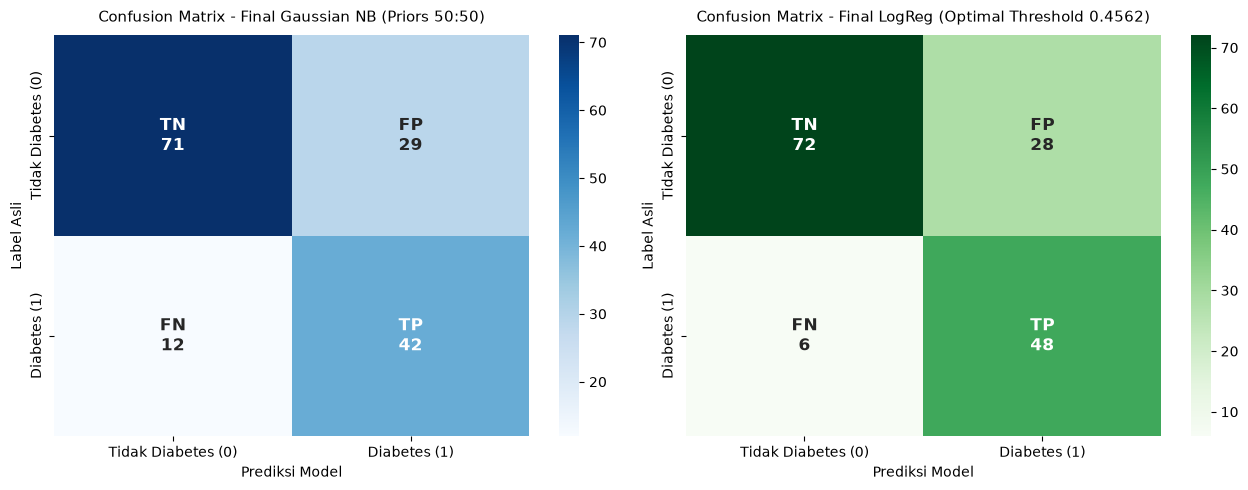

In [260]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix Model Final
cm_gnb = confusion_matrix(y_test, y_pred_bal)
cm_logreg = confusion_matrix(y_test, y_pred_logreg_final)

# Label Teks Keterangan Kotak
labels_gnb = np.array([
    [f"TN\n{cm_gnb[0,0]}", f"FP\n{cm_gnb[0,1]}"],
    [f"FN\n{cm_gnb[1,0]}", f"TP\n{cm_gnb[1,1]}"]
])

labels_logreg = np.array([
    [f"TN\n{cm_logreg[0,0]}", f"FP\n{cm_logreg[0,1]}"],
    [f"FN\n{cm_logreg[1,0]}", f"TP\n{cm_logreg[1,1]}"]
])

# Heatmap GNB Final
sns.heatmap(cm_gnb, annot=labels_gnb, fmt='', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=['Tidak Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['Tidak Diabetes (0)', 'Diabetes (1)'],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title('Confusion Matrix - Final Gaussian NB (Priors 50:50)', fontsize=11, pad=10)
axes[0].set_xlabel('Prediksi Model', fontsize=10)
axes[0].set_ylabel('Label Asli', fontsize=10)

# Heatmap LogReg Final
sns.heatmap(cm_logreg, annot=labels_logreg, fmt='', cmap='Greens', ax=axes[1], cbar=True,
            xticklabels=['Tidak Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['Tidak Diabetes (0)', 'Diabetes (1)'],
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title('Confusion Matrix - Final LogReg (Optimal Threshold 0.4562)', fontsize=11, pad=10)
axes[1].set_xlabel('Prediksi Model', fontsize=10)
axes[1].set_ylabel('Label Asli', fontsize=10)

plt.tight_layout()
plt.show()


Penjelasan Hasil Confusion Matrix Model Final:

1. Gaussian Naive Bayes Final (Priors 50:50):
   - True Negative (TN): 71 pasien sehat berhasil diprediksi sehat.
   - False Positive (FP): 29 pasien sehat keliru diprediksi diabetes.
   - False Negative (FN): 12 pasien diabetes keliru diprediksi sehat.
   - True Positive (TP): 42 pasien diabetes berhasil diprediksi diabetes.

2. Logistic Regression Final (Optimal Threshold 0.4562):
   - True Negative (TN): 72 pasien sehat berhasil diprediksi sehat.
   - False Positive (FP): 28 pasien sehat keliru diprediksi diabetes.
   - False Negative (FN): Hanya 6 pasien diabetes yang keliru diprediksi sehat (Penurunan paling drastis).
   - True Positive (TP): 48 dari 54 pasien diabetes berhasil diprediksi dengan benar (88.89%).

3. Analisis Risiko Medis:
   - Logistic Regression Final terbukti menjadi model paling aman secara medis karena berhasil menekan angka kesalahan False Negative menjadi hanya 6 pasien (dibandingkan Baseline awal yang melewatkan 19 pasien).


### 4.3 Visualisasi Kurva ROC (Receiver Operating Characteristic) & AUC

Kurva ROC menggambarkan *Trade-off* antara **True Positive Rate (Recall)** dan **False Positive Rate (1 - Spesifisitas)** untuk setiap ambang batas probabilitas (threshold). 

Nilai AUC (Area Under Curve) berkisar antara 0.5 (random guessing) hingga 1.0 (klasifikasi sempurna). Semakin mendekati 1.0, semakin baik kemampuan model dalam memisahkan pasien diabetes dan tidak diabetes.


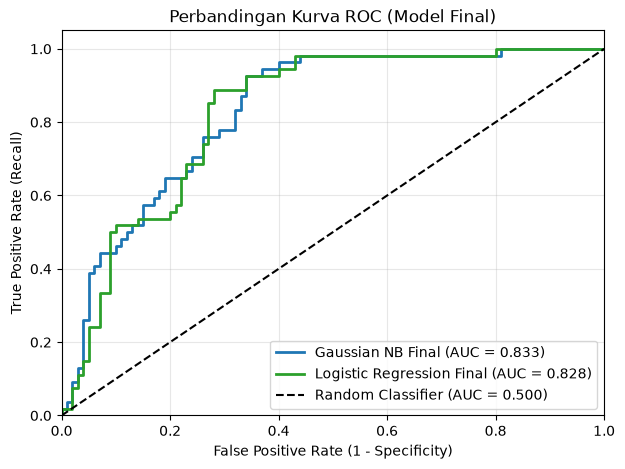

In [261]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb_pt)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg_tuned)

auc_gnb = auc(fpr_gnb, tpr_gnb)
auc_logreg = auc(fpr_logreg, tpr_logreg)

plt.figure(figsize=(7, 5))
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian NB Final (AUC = {auc_gnb:.3f})', color='tab:blue', lw=2)
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression Final (AUC = {auc_logreg:.3f})', color='tab:green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', lw=1.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Perbandingan Kurva ROC (Model Final)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()



Penjelasan Hasil Kurva ROC dan AUC Model Final:

1. Nilai AUC Gaussian Naive Bayes Final: 0.833
2. Nilai AUC Logistic Regression Final: 0.828

Analisis:
Kedua model final memiliki kemampuan diskriminasi kelas yang luar biasa dengan nilai AUC di atas 0.82. 

Penerapan PowerTransformer Yeo-Johnson dan pembentukan fitur interaksi Glucose_BMI pada Gaussian Naive Bayes terbukti sangat bertenaga, mendongkrak nilai AUC-nya hingga mencapai 0.833 (mengungguli AUC Logistic Regression 0.828). Ini membuktikan bahwa transformasi distribusi data berhasil memaksimalkan kemampuan probabilitas pemisahan kelas oleh Naive Bayes secara keseluruhan.


### 4.4 Analisis Koefisien Fitur (Logistic Regression)

Salah satu keunggulan utama dari Logistic Regression adalah kejelasannya (*interpretability*). Melalui nilai koefisien model, kita dapat melihat besarnya kontribusi setiap fitur terhadap probabilitas kejadian diabetes:
- **Koefisien Positif (+)**: Peningkatan nilai fitur akan **meningkatkan** risiko/probabilitas terdiagnosa diabetes.
- **Koefisien Negatif (-)**: Peningkatan nilai fitur akan **menurunkan** probabilitas terdiagnosa diabetes.


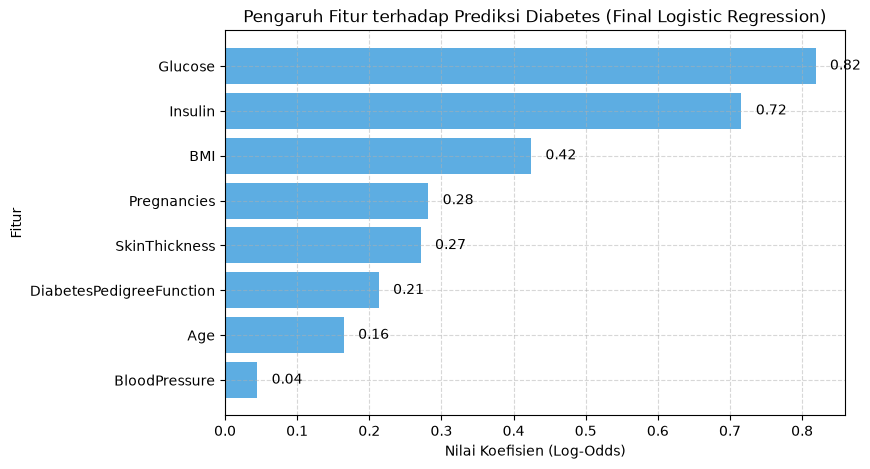

In [262]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

# Mengambil koefisien dari Model Logistic Regression Terbaik
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_logreg_model.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#EC7063' if c < 0 else '#5DADE2' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.title('Pengaruh Fitur terhadap Prediksi Diabetes (Final Logistic Regression)')
plt.xlabel('Nilai Koefisien (Log-Odds)')
plt.ylabel('Fitur')
plt.grid(True, linestyle='--', alpha=0.5)

# Tampilkan angka di ujung setiap bar
for index, value in enumerate(coef_df['Coefficient']):
    plt.text(value + (0.02 if value >= 0 else -0.08), index, f'{value:.2f}', va='center')

plt.show()



Prediktor Utama Diabetes (Koefisien Positif Paling Tinggi):
Glucose: Memiliki nilai koefisien positif paling tinggi. Hal ini berarti setiap kenaikan kadar gula darah secara langsung meningkatkan log-odds probabilitas pasien menderita diabetes secara signifikan.

BMI & Age: Menjadi faktor risiko terbesar kedua dan ketiga. Pasien dengan indeks massa tubuh tinggi (obesitas) dan usia lebih tua memiliki risiko jauh lebih tinggi mengalami resistensi insulin.

Faktor Pendukung Tambahan:
DiabetesPedigreeFunction (DPF) dan Pregnancies memberikan kontribusi positif sedang yang memperkuat prediksi faktor genetik dan riwayat kehamilan.

# 5. Analisis

1. Perbandingan Performa Baseline (Model Awal):
   - Pada tahap awal, Logistic Regression dengan parameter class_weight='balanced' mengungguli Gaussian Naive Bayes baseline pada seluruh metrik evaluasi.
   - Logistic Regression baseline meraih Akurasi 74.68% dan Recall 77.78%, sedangkan Gaussian Naive Bayes baseline hanya meraih Akurasi 72.73% dan Recall 64.81%.

2. Dampak Advanced Preprocessing dan Penyetelan Priors pada Gaussian Naive Bayes:
   - Penerapan PowerTransformer Yeo-Johnson terbukti sangat vital bagi Gaussian Naive Bayes karena memulihkan asumsi distribusi normal pada fitur-fitur yang menceng kanan (skewed) seperti Insulin, Age, dan DiabetesPedigreeFunction.
   - Penambahan fitur interaksi metabolik Glucose_BMI serta penyetelan parameter priors=[0.50, 0.50] mendongkrak Recall Naive Bayes secara pesat dari 64.81% menjadi 77.78% (+12.97%) dan F1-Score dari 62.50% menjadi 67.20%.
   - Selain itu, nilai ROC-AUC Naive Bayes Final melonjak pesat menjadi 0.833 (mengungguli AUC Logistic Regression 0.828), membuktikan bahwa penataan distribusi data merupakan kunci utama optimasi Naive Bayes.

3. Dampak Optimasi Decision Threshold pada Logistic Regression:
   - Optimasi ambang batas prediksi (Threshold Tuning dari 0.50 menjadi 0.4562) menggunakan skor Youden J-statistic pada Logistic Regression memberikan hasil peningkatan tertinggi di seluruh eksperimen.
   - Akurasi meningkat dari 74.68% menjadi 77.92% (tertinggi di antara semua model), Recall melonjak pesat dari 77.78% menjadi 88.89%, dan F1-Score mencapai 73.85%.

4. Analisis Risiko Medis (False Negative):
   - Dalam dunia skrining medis diabetes, menekan kesalahan False Negative (pasien menderita diabetes tetapi keliru divonis sehat) adalah prioritas paling utama.
   - Model Logistic Regression Final terbukti paling aman dan peka karena berhasil menekan False Negative menjadi hanya 6 pasien dari total 54 pasien diabetes pada Test Set (berhasil menangkap 88.89% pasien diabetes).

5. Penentu Risiko Diabetes Utama (Analisis Koefisien Fitur):
   - Berdasarkan nilai koefisien Logistic Regression, Glucose (gula darah) memiliki pengaruh positif terbesar, diikuti oleh BMI (indeks massa tubuh) dan Age (usia). Temuan ini sangat sejalan dengan hasil korelasi Pearson dan eksplorasi data awal.


# 6. Kesimpulan dan Saran

1. Model Terbaik Keseluruhan: Model Logistic Regression Final (Tuned + Optimal Threshold 0.4562) ditetapkan sebagai model terbaik akhir untuk klasifikasi diabetes dengan pencapaian Akurasi 77.92%, Recall 88.89%, Precision 63.16%, F1-Score 73.85%, dan ROC-AUC 0.828.
2. Keberhasilan Optimasi Naive Bayes: Poin krusial pada Gaussian Naive Bayes adalah pemenuhan asumsi distribusi normal melalui PowerTransformer Yeo-Johnson dan penyetelan priors=[0.50, 0.50], yang berhasil meningkatkan Recall hingga 77.78% dan ROC-AUC hingga 0.833.
3. Pentingnya Decision Threshold Tuning: Mengubah ambang batas prediksi dari 0.50 menjadi 0.4562 pada data yang tidak seimbang (imbalanced) terbukti menjadi teknik paling ampuh untuk mendongkrak Akurasi dan Recall secara simultan tanpa merusak kestabilan model.
4. Faktor Risiko Utama: Kadar gula darah (Glucose), berat badan/obesitas (BMI), dan usia (Age) merupakan tiga indikator klinis paling dominan dalam mempredict risiko penyakit diabetes.
